# Unassigned Transcripts

In [ ]:
import pandas as pd
from module.misc import genes_list

In [ ]:
# df = pd.read_parquet('../data/circa4-IGM-ZT01/transcripts.parquet',
#                      columns=['feature_name', 'cell_id','qv'],
#                     #  filters = [('feature_name', '==', gene)]
#                      )

# samples = ['3159-4','3161-3']

# samples = [
#     # 'CTRL-68-1__20240517__205823',
#     'CTRL-94-1__20240517__205823', 'WFF-64-1__20240517__205823',
# 'WFF-64-2__20240517__205823', 'WFF-66-1__20240517__205823', 'WFF-66-2__20240517__205823']

samples = ['circa4-IGM-ZT01','circa4-IGM-ZT05','circa4-IGM-ZT09','circa4-IGM-ZT13','circa4-IGM-ZT17','circa4-IGM-ZT21',
           "SD1-ZT01","SD1-ZT05","SD1-ZT09","SD1-ZT13","SD1-ZT17","SD1-ZT21",
           ]

for sample in samples:
    print(f'start sample : {sample}')
    df = pd.read_parquet(fr'../data/{sample}/transcripts.parquet',
    # df = pd.read_parquet(fr'I:\Xenium\Laura\saggital\{sample}\transcripts.parquet',
                        columns=['feature_name', 'cell_id','qv'],
                        filters = [('qv', '>=', 20)]
                        )
    
    df = df[(~df['feature_name'].str.contains('_'))]

    panel = genes_list('panel_5k')

    ddf_table = pd.DataFrame(index = panel)
    ddf_table['transcripts_0'] = 0
    ddf_table['transcripts_20'] = 0
    ddf_table['ratio_qv20'] = 0
    ddf_table['ratio_UNASSIGNED'] = 0


    # df['qv_modified'] = df.apply(lambda x: "20" if x['qv']>=20 else "0", axis = 1)
    df['unassigned'] = df.apply(lambda x: "UNASSIGNED" if x['cell_id']=="UNASSIGNED" else "ASSIGNED", axis = 1)

    # ddf = df.groupby(['qv_modified','feature_name'])['feature_name'].value_counts()

    ddf_assigned = df.groupby(['unassigned','feature_name'])['feature_name'].value_counts()

    # ddf_assigned_qv = df[df['qv_modified']=="20"].groupby(['unassigned','feature_name'])['feature_name'].value_counts()

    # ddf_table['transcripts_0'] = ddf["0"]
    # ddf_table['transcripts_20'] = ddf["20"]
    # ddf_table['total'] = ddf_table['transcripts_0'] + ddf_table['transcripts_20']
    # ddf_table['ratio_qv20'] = ddf["20"] / (ddf["0"]+ddf["20"])
    ddf_table['UNASSIGNED'] = ddf_assigned['UNASSIGNED']
    ddf_table['ASSIGNED'] = ddf_assigned['ASSIGNED']
    ddf_table['total'] = ddf_table['UNASSIGNED'] + ddf_table['ASSIGNED']
    ddf_table['ratio_UNASSIGNED'] = ddf_assigned['UNASSIGNED'] / ddf_table['total']
    # ddf_table['UNASSIGNED_qv20'] = ddf_assigned_qv['UNASSIGNED']
    # ddf_table['ASSIGNED_qv20'] = ddf_assigned_qv['ASSIGNED']
    # ddf_table['ratio_UNASSIGNED_qv20'] = ddf_assigned_qv['UNASSIGNED'] / (ddf_assigned_qv['UNASSIGNED'] + ddf_assigned_qv['ASSIGNED'])

    ddf_table.to_csv(f'data/{sample}_unassigned-ratio.csv')

In [ ]:
sample = '3159-4'
ddf_table = pd.read_csv(f'data/{sample}_unassigned-ratio.csv')
ddf_table.index = ddf_table['Unnamed: 0']

sample2 = '3161-3'
ddf_table2 = pd.read_csv(f'data/{sample2}_unassigned-ratio.csv')
ddf_table2.index = ddf_table2['Unnamed: 0']

In [ ]:
directory = r'D:\Temp\Unassigned_analysis\all-samples\CTX'

sample = '3159-2'
ddf_table = pd.read_csv(f'{directory}/CTX_{sample}_unassigned-ratio.csv')
ddf_table.index = ddf_table['Unnamed: 0']

sample2 = '3161-1'
ddf_table2 = pd.read_csv(f'{directory}/CTX_{sample2}_unassigned-ratio.csv')
ddf_table2.index = ddf_table2['Unnamed: 0']

In [ ]:
ddf_table2

In [ ]:
import matplotlib.pyplot as plt
# fig, ax = plt.subplots(1,1, figsize= (14,4), sharey=True, sharex=True)
# ax = ax.flatten()
plt.figure(figsize=(6,4))
plt.scatter(x= ddf_table['total'], y = ddf_table['ratio_UNASSIGNED'], s=8)
plt.xscale('log')
for gene in ddf_table[ddf_table['ratio_UNASSIGNED']>0.6].index:
    plt.text(x= ddf_table['total'][gene],
             y = ddf_table['ratio_UNASSIGNED'][gene], s=gene, ha= 'center')

plt.xlabel('log transcripts number')
plt.ylabel('Unassigned transcript ratio')
# plt.title('Whole brain section - WT')
plt.ylim(0,1)
plt.savefig(f'Gallery/{today}/UNA_RAT_WHO.svg', transparent = True, dpi = 300)

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,2, figsize= (14,4), sharey=True, sharex=True)
ax = ax.flatten()

ax[0].scatter(x= ddf_table['total'], y = ddf_table['ratio_UNASSIGNED'], s=8)
ax[0].set_xscale('log')
for gene in ddf_table[ddf_table['ratio_UNASSIGNED']>0.66].index:
    ax[0].text(x= ddf_table['total'][gene],
             y = ddf_table['ratio_UNASSIGNED'][gene], s=gene, ha= 'center')

ax[0].set_xlabel('log transcripts number')
ax[0].set_ylabel('Unassigned transcript ratio')
ax[0].set_title('Whole brain section - WT')
ax[0].set_ylim(0,1)

ax[1].scatter(x= ddf_table2['total'], y = ddf_table2['ratio_UNASSIGNED'], s=8)
ax[1].set_xscale('log')
for gene in ddf_table2[ddf_table2['ratio_UNASSIGNED']>0.66].index:
    ax[1].text(x= ddf_table2['total'][gene],
             y = ddf_table2['ratio_UNASSIGNED'][gene], s=gene, ha= 'center' )

ax[1].set_xlabel('log transcripts number')
ax[1].set_ylabel('Unassigned transcript ratio')
ax[1].set_title('Whole brain section - APP')



# plt.savefig(f'Gallery/{today}/WT_Unassigned_transcripts_ratio_per_transcripts_number.svg')


In [ ]:
plt.scatter(x= ddf2['ratio_UNASSIGNED'], y = ddf2['ratio_UNASSIGNED_qv20'], s=1.5)
# for gene in ddf2.index:
#     plt.text(x= ddf2['ratio_UNASSIGNED'][gene], y = ddf2['ratio_UNASSIGNED_qv20'][gene], s=gene)
plt.xlabel('ratio_unassigned')
plt.ylabel('ratio_unassigned_qv20')

In [ ]:
plt.scatter(x= ddf2['total'], y = ddf2['ratio_qv20'], s=0.75)
plt.xscale("log")

In [ ]:
plt.scatter(x= ddf2['total'], y = ddf2['ratio_UNASSIGNED_qv20'], s=0.75)
plt.xscale("log")


# Transcripts assigments to resegmented cells

In [ ]:
import geojson
import pandas as pd
import geopandas as gpd
import os

In [ ]:
import pickle
with open(f"../notebook/analysis/all-samples/region_area.pickle", "rb") as handle:
    dict_area = pickle.load(handle)

dict_area.keys()

In [ ]:
### Reassign transcripts into resegmented cells
samples = ["2505-1","3160-1","3160-2","2505-2","2670-1","3159-1"]

for sample in samples:
    directory = f'../../aidan/data/new-region-split/{sample}/'
    list_files = os.listdir(directory)
    list_regions = [file.split('_')[0] for file in list_files]

    for region in list_regions:
        print(sample," : ", region)
        df = pd.read_parquet(f'../../aidan/data/new-region-split/{sample}/{region}_transcripts_{sample}.parquet',
                            columns=['feature_name','cell_id','x_location', 'y_location']
                            )

        df = df[(~df['feature_name'].str.contains('_'))]
        df['feature_name'].value_counts()

        ## Transfo df into geopandas format as points
        features = []
        for idx in range(len(df)):
            coordinates = (float(df.loc[idx, 'x_location']/0.2125),float(df.loc[idx, 'y_location']/0.2125))
            point = geojson.Point((coordinates))
            feature = geojson.Feature(geometry=point, properties = {"feature_name":df.loc[idx, "feature_name"]})
            features.append(feature)

        feature_collection = geojson.FeatureCollection(features)

        # Save the GeoJSON FeatureCollection to a file
        with open(f'data/{sample}/{region}_transcripts_{sample}.geojson', 'w') as f:
            geojson.dump(feature_collection, f)

# Relabel transcripts as ASSIGNED or UNASSIGNED

In [ ]:
# Relabel transcripts as ASSIGNED or UNASSIGNED for resegmented samples
dict_temp = {'UNASSIGNED':'UNASSIGNED'}

samples = ["3160-2"]


for sample in samples:
    df_cell = gpd.read_file(f'/media/volume/volume_spatial/hugo/data/resegment_geojson/{sample}.geojson')

    directory = f'../../aidan/data/new-region-split/{sample}/'
    list_files = os.listdir(directory)
    list_regions = [file.split('_')[0] for file in list_files]
    print(list_regions)

    for region in list_regions:
        print(sample,' : ', region)
        ddf = gpd.read_file(f'data/{sample}/{region}_transcripts_{sample}.geojson')

        df_cell = df_cell[~(df_cell['objectType']=="annotation")]
        df_cell.head(3)

        ddf.crs = 'EPSG:4326'
        df_cell.crs = 'EPSG:4326'

        matched_cells = gpd.sjoin(ddf, df_cell, predicate='within', how='left')

        matched_cells.drop(['objectType', 'measurements','index_right'], axis = 1)

        matched_cells['id'] = matched_cells['id'].fillna("UNASSIGNED")
        matched_cells['id_bis'] = "ASSIGNED"

        matched_cells['id_bis'] = matched_cells['id'].map(dict_temp)
        matched_cells['id_bis'] = matched_cells['id_bis'].fillna("ASSIGNED")
        
        matched_cells.to_parquet(f'data/{sample}/fixed/{region}_transcripts_{sample}_fixed.parquet')

In [ ]:
# Extract ASSIGNED, UNASSIGNED, ratio and density for **re-segmented** samples
import os
from module.misc import genes_list

samples = ["3160-2", "3160-1"]

for sample in samples:
    print(f'start sample : {sample}')

    directory = f'../../aidan/data/new-region-split/{sample}'
    directory2 = f'data/{sample}'
    list_files = os.listdir(directory)
    if list_files.__contains__("use"):
        list_files.remove("use")
    list_regions = [file.split('_')[0] for file in list_files]
    
    for region in list_regions:
        print(sample," : ", region)
        df = pd.read_parquet(fr'{directory2}/fixed/{region}_transcripts_{sample}_fixed.parquet', columns=['feature_name', 'id_bis'])

        panel = genes_list('brain_panel')
        ddf_table = pd.DataFrame(index = panel)

        ddf_assigned = df.groupby(['id_bis','feature_name'])['id_bis'].value_counts()

        ddf_table['UNASSIGNED'] = ddf_assigned['UNASSIGNED']
        ddf_table['ASSIGNED'] = ddf_assigned['ASSIGNED']
        ddf_table['total'] = ddf_table['UNASSIGNED'] + ddf_table['ASSIGNED']
        ddf_table['ratio_UNASSIGNED'] = ddf_assigned['UNASSIGNED'] / ddf_table['total']
        ddf_table['UNASSIGNED_per_nm2'] = ddf_table['UNASSIGNED'] / dict_area[sample][region]
        ddf_table['ASSIGNED_per_nm2'] = ddf_table['ASSIGNED'] / dict_area[sample][region]
        ddf_table.to_csv(f'{directory2}/{region}_{sample}_unassigned-ratio.csv')

In [ ]:
# Extract ASSIGNED, UNASSIGNED, ratio and density for **Xenium-segmented** samples
import os
from module.misc import genes_list

samples = [
    "3161-1","3161-2","3161-3",
    # '3159-2','3159-3',
        #    "3159-4"
           ]

for sample in samples:
    print(f'start sample : {sample}')

    directory = f'../../aidan/data/new-region-split/{sample}'
    directory2 = f'data/{sample}'
    list_files = os.listdir(directory)
    if list_files.__contains__("use"):
        list_files.remove("use")
    list_regions = [file.split('_')[0] for file in list_files]
    
    for region in list_regions:
        print(sample," : ", region)
        df = pd.read_parquet(fr'{directory}/{region}_transcripts_{sample}.parquet')

        df['unassigned'] = df.apply(lambda x: "UNASSIGNED" if x['cell_id']=="UNASSIGNED" else "ASSIGNED", axis = 1)

        panel = genes_list('brain_panel')
        ddf_table = pd.DataFrame(index = panel)

        ddf_assigned = df.groupby(['unassigned','feature_name'])['feature_name'].value_counts()

        ddf_table['UNASSIGNED'] = ddf_assigned['UNASSIGNED']
        ddf_table['ASSIGNED'] = ddf_assigned['ASSIGNED']
        ddf_table['total'] = ddf_table['UNASSIGNED'] + ddf_table['ASSIGNED']
        ddf_table['ratio_UNASSIGNED'] = ddf_assigned['UNASSIGNED'] / ddf_table['total']
        ddf_table['UNASSIGNED_per_nm2'] = ddf_table['UNASSIGNED'] / dict_area[sample][region]
        ddf_table['ASSIGNED_per_nm2'] = ddf_table['ASSIGNED'] / dict_area[sample][region]
        ddf_table.to_csv(f'{directory2}/{region}_{sample}_unassigned-ratio.csv')

In [ ]:
# Extract ASSIGNED, UNASSIGNED, ratio and density for **Xenium-segmented** samples #### 5K prime panel
import os
from module.misc import genes_list
import pandas as pd

with open(f"data/dict_area.pickle", "rb") as handle:
    dict_area = pickle.load(handle)

samples = ['circa4-IGM-ZT05','circa4-IGM-ZT09','circa4-IGM-ZT13','circa4-IGM-ZT17','circa4-IGM-ZT21',
           ]

for sample in samples:
    print(f'start sample : {sample}')

    directory = f'../data/{sample}/splitregion'
    directory2 = f'data/unassigned/{sample}'
    list_files = os.listdir(directory)
    if list_files.__contains__("use"):
        list_files.remove("use")
    list_regions = [file.split('_')[0] for file in list_files]
    
    for region in list_regions:
        print(sample," : ", region)
        df = pd.read_parquet(fr'{directory}/{region}_transcripts_{sample}.parquet')

        df['unassigned'] = df.apply(lambda x: "UNASSIGNED" if x['cell_id']=="UNASSIGNED" else "ASSIGNED", axis = 1)

        panel = genes_list('panel_5k')
        ddf_table = pd.DataFrame(index = panel)

        ddf_assigned = df.groupby(['unassigned','feature_name'])['feature_name'].value_counts()

        ddf_table['UNASSIGNED'] = ddf_assigned['UNASSIGNED']
        ddf_table['ASSIGNED'] = ddf_assigned['ASSIGNED']
        ddf_table['total'] = ddf_table['UNASSIGNED'] + ddf_table['ASSIGNED']
        ddf_table['ratio_UNASSIGNED'] = ddf_assigned['UNASSIGNED'] / ddf_table['total']
        ddf_table['UNASSIGNED_per_nm2'] = ddf_table['UNASSIGNED'] / dict_area[sample][region]
        ddf_table['ASSIGNED_per_nm2'] = ddf_table['ASSIGNED'] / dict_area[sample][region]
        ddf_table.to_csv(f'{directory2}/{region}_{sample}_unassigned-ratio.csv')

start sample : circa4-IGM-ZT05
circa4-IGM-ZT05  :  CTX
circa4-IGM-ZT05  :  AHN
circa4-IGM-ZT05  :  SMT
circa4-IGM-ZT05  :  PVT
circa4-IGM-ZT05  :  AV
circa4-IGM-ZT05  :  LSX
circa4-IGM-ZT05  :  PVH
circa4-IGM-ZT05  :  SCH
circa4-IGM-ZT05  :  STR
circa4-IGM-ZT05  :  RE
circa4-IGM-ZT05  :  PT
circa4-IGM-ZT05  :  AD
circa4-IGM-ZT05  :  AMY
circa4-IGM-ZT05  :  RT ZI
circa4-IGM-ZT05  :  LHA
start sample : circa4-IGM-ZT09
circa4-IGM-ZT09  :  AMY
circa4-IGM-ZT09  :  LHA
circa4-IGM-ZT09  :  PVH
circa4-IGM-ZT09  :  PVT
circa4-IGM-ZT09  :  SCH
circa4-IGM-ZT09  :  AHN
circa4-IGM-ZT09  :  LSX
circa4-IGM-ZT09  :  CTX
circa4-IGM-ZT09  :  STR
start sample : circa4-IGM-ZT13
circa4-IGM-ZT13  :  SMT
circa4-IGM-ZT13  :  LH
circa4-IGM-ZT13  :  CTX
circa4-IGM-ZT13  :  HIPP
circa4-IGM-ZT13  :  LD
circa4-IGM-ZT13  :  AMY
circa4-IGM-ZT13  :  MH
circa4-IGM-ZT13  :  RE
circa4-IGM-ZT13  :  PVT
circa4-IGM-ZT13  :  RT ZI
circa4-IGM-ZT13  :  SCH
circa4-IGM-ZT13  :  PVH
circa4-IGM-ZT13  :  STR
circa4-IGM-ZT13  :  AH

In [ ]:
# Extract ASSIGNED, UNASSIGNED, ratio and density for **Xenium-segmented** samples #### 5K prime panel
import os
from module.misc import genes_list
import pandas as pd

with open(f"data/dict_area.pickle", "rb") as handle:
    dict_area = pickle.load(handle)

samples = ['SD1-ZT01','SD1-ZT05','SD1-ZT09','SD1-ZT13','SD1-ZT17','SD1-ZT21',
           ]

for sample in samples:
    print(f'start sample : {sample}')

    directory = f'../data/{sample}/splitregion'
    directory2 = f'data/unassigned/{sample}'
    list_files = os.listdir(directory)
    if list_files.__contains__("use"):
        list_files.remove("use")
    list_regions = [file.split('_')[0] for file in list_files]
    
    for region in list_regions:
        print(sample," : ", region)
        df = pd.read_parquet(fr'{directory}/{region}_transcripts_{sample}.parquet')

        df['unassigned'] = df.apply(lambda x: "UNASSIGNED" if x['cell_id']=="UNASSIGNED" else "ASSIGNED", axis = 1)

        panel = genes_list('panel_5k')
        ddf_table = pd.DataFrame(index = panel)

        ddf_assigned = df.groupby(['unassigned','feature_name'])['feature_name'].value_counts()

        ddf_table['UNASSIGNED'] = ddf_assigned['UNASSIGNED']
        ddf_table['ASSIGNED'] = ddf_assigned['ASSIGNED']
        ddf_table['total'] = ddf_table['UNASSIGNED'] + ddf_table['ASSIGNED']
        ddf_table['ratio_UNASSIGNED'] = ddf_assigned['UNASSIGNED'] / ddf_table['total']
        ddf_table['UNASSIGNED_per_nm2'] = ddf_table['UNASSIGNED'] / dict_area[sample][region]
        ddf_table['ASSIGNED_per_nm2'] = ddf_table['ASSIGNED'] / dict_area[sample][region]
        ddf_table.to_csv(f'{directory2}/{region}_{sample}_unassigned-ratio.csv')

## Plot

In [ ]:
import pandas as pd

df = pd.read_excel(rf'D:\Temp\Unassigned_analysis\Summary_all_samples.xlsx', sheet_name=None)
df_filter = {}
for key in df.keys():
    df[key].index = df[key]['gene']
    df_filter[key] = df[key][(df[key]['t.test']<=0.05) & (abs(df[key]['FC'])>0.5)]
print(df.keys())

dict_keys(['CTX_Unassigned_density', 'SCH_UNA_DEN', 'HIPP_UNA_DEN'])


C:\Users\hcall\AppData\Local\Temp\ipykernel_16928\3122348868.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(df_filter[key]['FC'][idx],
C:\Users\hcall\AppData\Local\Temp\ipykernel_16928\3122348868.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_filter[key]['t.test'][idx], str(gene), color = 'black', fontsize = 8, ha= 'center')


Text(0.5, 1.0, 'CTX_Unassigned_density')

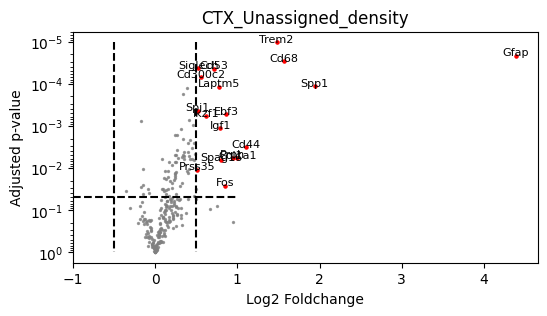

In [ ]:
import matplotlib.pyplot as plt

key = 'CTX_Unassigned_density'

plt.figure(figsize=(6,3))

plt.vlines(x=(-0.5,0.5), ymin=df_filter[key]['t.test'].min(), ymax=1, color = "black", linestyles='dashed')
plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')

plt.scatter(x=df[key]['FC'], y = df[key]['t.test'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= df_filter[key]['FC'], y=df_filter[key]['t.test'], s=5, alpha=1, color = 'red')

for idx, gene in enumerate(df_filter[key]['gene']):
    plt.text(df_filter[key]['FC'][idx],
    df_filter[key]['t.test'][idx], str(gene), color = 'black', fontsize = 8, ha= 'center')
    
plt.yscale('log')
plt.xlim(-1,)
# plt.ylim(0,100000)
plt.gca().invert_yaxis()
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
plt.title(f"{key}")
# plt.savefig(f'Gallery/{today}/volcano_plot_{key}-Unassigned.svg')

# Cytoplasm vs nucleus

In [ ]:
from module.misc import genes_list
import scanpy as sc
import pandas as pd

gene_list = genes_list("brain_panel")
sample = '3161-2'
region = 'CTX'


In [ ]:
adata = sc.read_h5ad(f'D:/Jupyter_notebook/Xenium_jupyter_notebook/h5ad/all-samples/all-samples_final.h5ad.gz')

In [ ]:
adata = adata[adata.obs['sample']==sample]
list_cell = adata[adata.obs['region_automap_name']==region].obs['cell_id'].values

In [ ]:
list_cell = [cell.split('_')[1] for cell in list_cell]
list_cell

['aaaafenj-1',
 'aaaafhjo-1',
 'aaaahpjl-1',
 'aaaakefj-1',
 'aaaallbk-1',
 'aaacepfl-1',
 'aaachpjb-1',
 'aaaclkef-1',
 'aaadbana-1',
 'aaadpapo-1',
 'aaagcjoc-1',
 'aaagiibm-1',
 'aaahbphd-1',
 'aaahmnfa-1',
 'aaaieled-1',
 'aaaienbd-1',
 'aaaifjoe-1',
 'aaaihahi-1',
 'aaaimbln-1',
 'aaajghmf-1',
 'aaajhfaj-1',
 'aaakedpn-1',
 'aaakgmaa-1',
 'aaakjagj-1',
 'aaalkkco-1',
 'aaalknki-1',
 'aaallfmi-1',
 'aaalmiph-1',
 'aaalnikc-1',
 'aaamdgnh-1',
 'aaammnkd-1',
 'aaanmaag-1',
 'aabacegb-1',
 'aabahoik-1',
 'aabakdoi-1',
 'aabakkgo-1',
 'aabapjnl-1',
 'aabbfnoe-1',
 'aabbhbdo-1',
 'aabbllgf-1',
 'aabbmfhk-1',
 'aabbmkik-1',
 'aabbmnnf-1',
 'aabbolgo-1',
 'aabcabeb-1',
 'aabcdaae-1',
 'aabcfbph-1',
 'aabclgdb-1',
 'aabcnldh-1',
 'aabehbdn-1',
 'aabehkmm-1',
 'aabelcbl-1',
 'aabenegp-1',
 'aabephbf-1',
 'aabfcbgp-1',
 'aabficdl-1',
 'aabgpgog-1',
 'aabhbdcn-1',
 'aabhigjm-1',
 'aabhndnl-1',
 'aabhopid-1',
 'aabidmao-1',
 'aabijlpd-1',
 'aabiodjk-1',
 'aabjiiem-1',
 'aabjohga-1',
 'aabjomoj

In [ ]:
df_transcripts = pd.read_parquet(f'D:/Xenium/{sample}/transcripts.parquet',
                                 columns=["cell_id",'feature_name','overlaps_nucleus' ],
                                 filters=[('qv', '>=', 20),
                                          ("feature_name","in",gene_list),
                                          ('cell_id','in',list_cell)
                                          ])
df_transcripts.groupby('feature_name')['overlaps_nucleus'].value_counts().to_csv(f'data/overlap_nucleus_{sample}_CTX.csv')

In [ ]:
df_transcripts = pd.read_parquet(f'D:/Xenium/{sample}/transcripts.parquet',
                                 columns=["cell_id",'feature_name','overlaps_nucleus' ],
                                 filters=[('qv', '>=', 20),
                                          ("feature_name","in",gene_list),
                                          ('cell_id','==','UNASSIGNED')
                                          ])

df_transcripts['feature_name'].value_counts().to_csv(f'data/nb_transcripts_unassigned_{sample}_CTX.csv')